# Recommendation Engine

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/recommender/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/recommender/demo.ipynb)

> "We have no 'you may also like'" — item-item collaborative filtering, with explanations for every recommendation.

The recommendation that made Amazon Amazon - "customers who bought X also bought Y" - is
**item-item collaborative filtering**, and it's surprisingly simple: build a similarity matrix
between items from how users co-engage with them, then recommend neighbors of what someone already
likes. No training loop, and every recommendation is explainable.

**What this notebook covers**
1. The user-item matrix
2. Item-item similarity (cosine)
3. Similar-items lookup ("related products")
4. Personalized recommendations + *why*
5. The similarity matrix, visualized


## Step 1 - The user-item matrix

Rows are users, columns are items, values are ratings (0 = no interaction). Everything is derived
from this one table - no features, no model file.

In [1]:
from recommender import ItemItemCF, sample_interactions

df = sample_interactions()
print(df.to_string())


     Dune  Foundation  Neuromancer  The Martian  Salt Fat Acid Heat  The Food Lab  Mastering Pasta  Sapiens
Ada     5           5            4            4                   0             0                0        3
Ben     4           5            5            0                   0             1                0        4
Cy      5           4            0            5                   0             0                0        0
Dee     0           0            0            0                   5             5                4        0
Eli     0           0            1            0                   4             5                5        0
Fin     1           0            0            0                   5             4                0        4
Gus     0           0            0            1                   0             0                5        5


## Step 2 - Items that co-occur are similar

Two items are similar if the same users rate them highly. Cosine similarity between item *columns*
captures exactly that - and the sci-fi books cluster apart from the cookbooks.

In [2]:
cf = ItemItemCF().fit(df)
print("Similar to 'Dune':")
for r in cf.similar_items("Dune", 3):
    print(f"   {r.item:<22} {r.score:.2f}")
print("\nSimilar to 'The Food Lab':")
for r in cf.similar_items("The Food Lab", 3):
    print(f"   {r.item:<22} {r.score:.2f}")


Similar to 'Dune':
   Foundation             0.98
   The Martian            0.85
   Neuromancer            0.75

Similar to 'The Food Lab':
   Salt Fat Acid Heat     0.98
   Mastering Pasta        0.68
   Sapiens                0.30


## Step 3 - Personalized recommendations, explained

For a user, score each unseen item by its similarity to what they already liked, weighted by their
ratings. Crucially, we can say *why* - the items in their history that drove each suggestion.

In [3]:
for user in ["Ada", "Dee"]:
    print(f"Recommendations for {user}:")
    for r in cf.recommend_for_user(user, 3):
        why = cf.explain(user, r.item)
        print(f"   {r.item:<22} score {r.score:.2f}  (because you liked: {', '.join(why)})")
    print()


Recommendations for Ada:
   The Food Lab           score 2.63  (because you liked: Sapiens, Neuromancer, Dune)
   Mastering Pasta        score 1.90  (because you liked: Sapiens, Neuromancer, The Martian)
   Salt Fat Acid Heat     score 1.59  (because you liked: Sapiens, Dune, Neuromancer)

Recommendations for Dee:
   Sapiens                score 4.53  (because you liked: Salt Fat Acid Heat, Mastering Pasta, The Food Lab)
   Neuromancer            score 1.70  (because you liked: The Food Lab, Salt Fat Acid Heat, Mastering Pasta)
   Dune                   score 0.97  (because you liked: The Food Lab, Salt Fat Acid Heat)



## Step 4 - The similarity matrix, visualized

The heatmap shows the block structure: sci-fi titles form one bright cluster, cookbooks another. The
recommender is just reading these blocks.

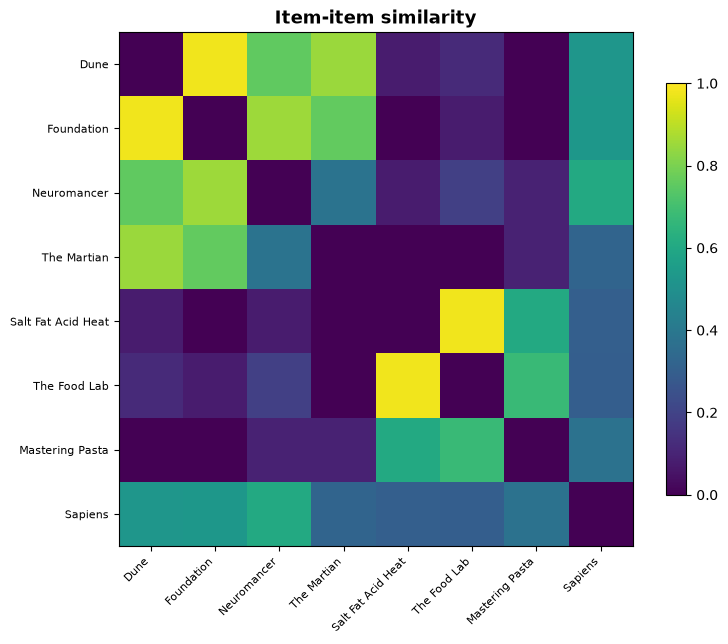

In [4]:
import matplotlib.pyplot as plt

sim = cf.item_sim
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(sim.values, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(sim.columns)))
ax.set_xticklabels(sim.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(sim.index)))
ax.set_yticklabels(sim.index, fontsize=8)
ax.set_title("Item-item similarity", fontsize=13, weight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("similarity.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Feature | How |
|---------|-----|
| related items | top cosine-similar columns |
| user recs | similarity-weighted sum over their ratings |
| explanation | the user's items most similar to the pick |

Item-item CF is the pragmatic first recommender: no training, cold-start-friendly for *users* (any
history yields recs), and explainable by construction. It's what powers most "you may also like"
rails before anyone reaches for deep learning.

**Extend it:** normalize for popularity bias, add implicit feedback (clicks/views), and blend with
content features for cold-start *items*.

In [5]:
# --- Try your own matrix ---
# import pandas as pd
# df = pd.DataFrame({"item_a": [...], "item_b": [...]}, index=["user1", "user2", ...])
# cf = ItemItemCF().fit(df)
# print(cf.recommend_for_user("user1"))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 117,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`